## DATA CLEANING


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('ola.csv')

In [ ]:
print("FIRST 5 ROWS")
print(df.head())

FIRST 5 ROWS
              datetime  season  weather   temp  humidity  windspeed  casual  \
0  2011-01-01 00:00:00       3        2   6.66     76.62       9.57       5   
1  2011-01-01 01:00:00       4        3  13.54     55.91       4.01      36   
2  2011-01-01 02:00:00       1        3  29.58     20.97      33.61      34   
3  2011-01-01 03:00:00       3        1   7.40     61.64      15.85       6   
4  2011-01-01 04:00:00       3        4  30.66     98.71      11.47      14   

   registered  count  
0         128    133  
1         184    220  
2          97    131  
3          47     53  
4         199    213  


In [ ]:
print("\n DATASET SUMMARY")
print(df.info())


 DATASET SUMMARY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        10886 non-null  float64
 4   humidity    10886 non-null  float64
 5   windspeed   10886 non-null  float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 765.6+ KB
None


### Check for missing/duplicate data

In [ ]:
print(df.isnull().sum())

datetime      0
season        0
weather       0
temp          0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [ ]:
print("\n DUPLICATE ROWS")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


 DUPLICATE ROWS
Number of duplicate rows: 0


### Fix the Datetime Data Type

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
print(df['datetime'].dtype)

datetime64[ns]


In [ ]:
# 1. Extract hour of the day (0 to 23)
df['hour'] = df['datetime'].dt.hour

# 2. Extract day of the week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['datetime'].dt.dayofweek

# 3. Extract month (1 to 12)
df['month'] = df['datetime'].dt.month

# 4. View your new columns
print(df[['datetime', 'hour', 'day_of_week', 'month']].head())

             datetime  hour  day_of_week  month
0 2011-01-01 00:00:00     0            5      1
1 2011-01-01 01:00:00     1            5      1
2 2011-01-01 02:00:00     2            5      1
3 2011-01-01 03:00:00     3            5      1
4 2011-01-01 04:00:00     4            5      1


### Handling seasons and weather

In [ ]:
# Convert season and weather into dummy/indicator columns
df = pd.get_dummies(df, columns=['season', 'weather'], drop_first=True)

# Look at the final cleaned columns ready for modeling
print(df.columns)

Index(['datetime', 'temp', 'humidity', 'windspeed', 'casual', 'registered',
       'count', 'hour', 'day_of_week', 'month', 'season_2', 'season_3',
       'season_4', 'weather_2', 'weather_3', 'weather_4'],
      dtype='object')


### Checking for outliers and anomalies

In [ ]:
print(df[['temp', 'humidity', 'windspeed', 'count']].describe())

               temp      humidity     windspeed         count
count  10886.000000  10886.000000  10886.000000  10886.000000
mean      20.137973     59.946072     24.960981    124.068988
std        8.696625     22.987200     14.424684     59.449265
min        5.000000     20.000000      0.000000      0.000000
25%       12.630000     40.040000     12.522500     74.000000
50%       20.190000     59.970000     25.000000    124.000000
75%       27.707500     79.620000     37.427500    174.000000
max       35.000000     99.980000     49.990000    248.000000


In [ ]:
df = df[df['humidity'] > 0]

In [ ]:
# Remove extreme windspeed anomalies (keeping values under 45)
df = df[df['windspeed'] < 45]

# Confirm that the extreme outliers are removed
print(df['windspeed'].max())

44.99


### Handling outliers using IQR

In [ ]:
# 1. Calculate IQR boundaries for the 'count' column
Q1 = df['count'].quantile(0.25)
Q3 = df['count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Filter the dataset to remove the statistical outliers
df_clean = df[(df['count'] >= lower_bound) & (df['count'] <= upper_bound)]

# 3. Print out how many rows were removed
print(f"Original rows: {len(df)}, Cleaned rows: {len(df_clean)}")

Original rows: 9796, Cleaned rows: 9796


In [ ]:
print(df.describe())

                            datetime         temp     humidity    windspeed  \
count                           9796  9796.000000  9796.000000  9796.000000   
mean   2011-08-15 13:55:49.734585600    20.134227    59.919161    22.455912   
min              2011-01-01 00:00:00     5.000000    20.000000     0.000000   
25%              2011-04-23 12:45:00    12.625000    40.020000    11.287500   
50%              2011-08-14 20:30:00    20.190000    59.975000    22.410000   
75%              2011-12-07 11:15:00    27.700000    79.512500    33.580000   
max              2012-03-29 13:00:00    35.000000    99.980000    44.990000   
std                              NaN     8.697363    22.990963    12.973527   

            casual   registered        count         hour  day_of_week  \
count  9796.000000  9796.000000  9796.000000  9796.000000  9796.000000   
mean     24.440384    99.491425   123.931809    11.512352     2.996938   
min       0.000000     0.000000     0.000000     0.000000     0.00

### ENCODING

In [ ]:
print(df_clean.columns)

Index(['datetime', 'temp', 'humidity', 'windspeed', 'casual', 'registered',
       'count', 'hour', 'day_of_week', 'month', 'season_2', 'season_3',
       'season_4', 'weather_2', 'weather_3', 'weather_4'],
      dtype='object')


## Exploratory Data Analysis (EDA) and Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### The Line Plot (Tracking Trends Over Time)

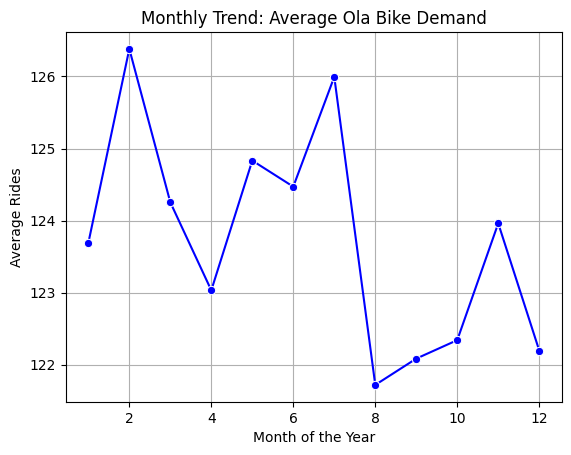

In [ ]:
monthly_demand = df_clean.groupby('month')['count'].mean().reset_index()
sns.lineplot(data=monthly_demand, x='month', y='count', marker='o', color='blue')
plt.title('Monthly Trend: Average Ola Bike Demand')
plt.xlabel('Month of the Year')
plt.ylabel('Average Rides')
plt.grid(True)
plt.show()

### Box Plot (Spotting Outliers and Spread)

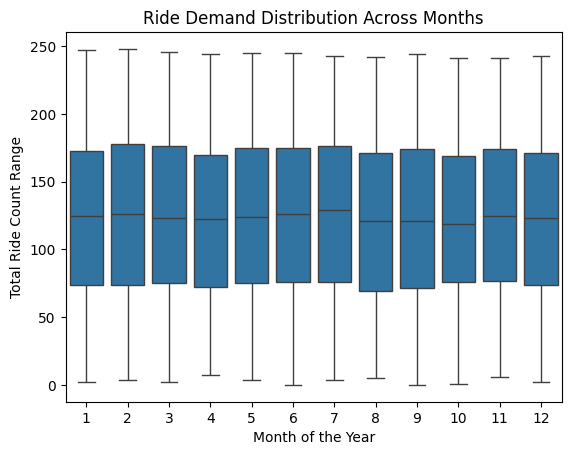

In [ ]:
sns.boxplot(data=df_clean, x='month', y='count')

plt.title('Ride Demand Distribution Across Months')
plt.xlabel('Month of the Year')
plt.ylabel('Total Ride Count Range')
plt.show()

### The Heatmap (Finding Correlation)

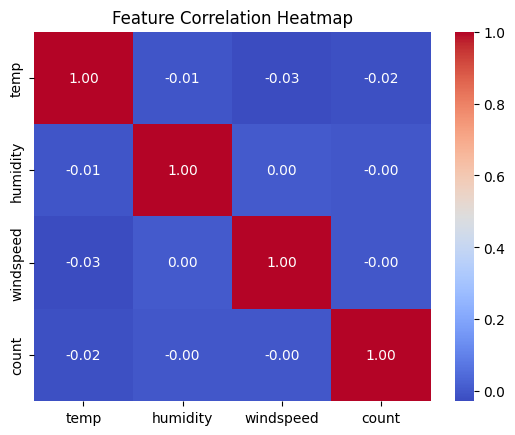

In [ ]:
weather_metrics = df_clean[['temp', 'humidity', 'windspeed', 'count']]
corr_matrix = weather_metrics.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Feature Correlation Heatmap')
plt.show()